In [1]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

import preprocessing.lipidomics as lipidomics
import alignment.alignment as alignment
from constants import MsiIntensityNormalization, DecompositionMethod

In [54]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/"
SAMPLE_ID = "TEST1530P"
MODALITY_NAME = "MSI"

OUTPUT_PATH =  os.path.join(PATH, SAMPLE_ID, 'preprocessing', MODALITY_NAME)

In [55]:
lipidomics.preprocess_lipidomics(
    path=PATH,
    sample_id=SAMPLE_ID,
    modality_name=MODALITY_NAME,
    peak_picking = True,
    prominence = 0.01,
    window_tolerance = 10,
    dynamic_window = True,
    dynamic_window_factor = 1e6,
    intensity_normalization=MsiIntensityNormalization.TIC,
    force_recomputation=True
)

Reading imzML file: /staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530P/MSI/pixel_test_pos_nor_15-30.imzML, associated with IBD file /staging/leuven/stg_00077/projects/Lorenzo/FOCUS/Nina/TEST1530P/MSI/pixel_test_pos_nor_15-30.ibd
Total unique M/Z values: 55088. Aligning with mass tolerance of 10 ppm and frequency threshold of 99.0 percentile.
After alignment 2973 M/Z values remain.


Aligning intensities to reference M/Z: 100%|██████████| 3573/3573 [00:00<00:00, 3809.67spectrum/s]


Applied Total Ion Current (TIC) normalization.


In [56]:
reference_mz = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_reference_mz.npy'))
intensities = np.load(os.path.join(OUTPUT_PATH, f'{SAMPLE_ID}_intensities_matrix.npy'))

In [57]:
print(f"Reference m/z shape: {reference_mz.shape}")
print(f"Intensities shape: {intensities.shape}")

Reference m/z shape: (2973,)
Intensities shape: (61, 83, 2973)


In [58]:
alignment_engine = alignment.Aligner(PATH, SAMPLE_ID)

In [62]:
msi_image = alignment_engine._generate_msi_image(OUTPUT_PATH, decomposition_method=DecompositionMethod.NMF)

In [63]:
# Flip the image across the y-axis
#msi_image = np.flip(msi_image, axis=1)
# Flip across the x-axis
msi_image = np.flip(msi_image, axis=0)

Text(0.5, 1.0, 'MSI Image for TEST1530P')

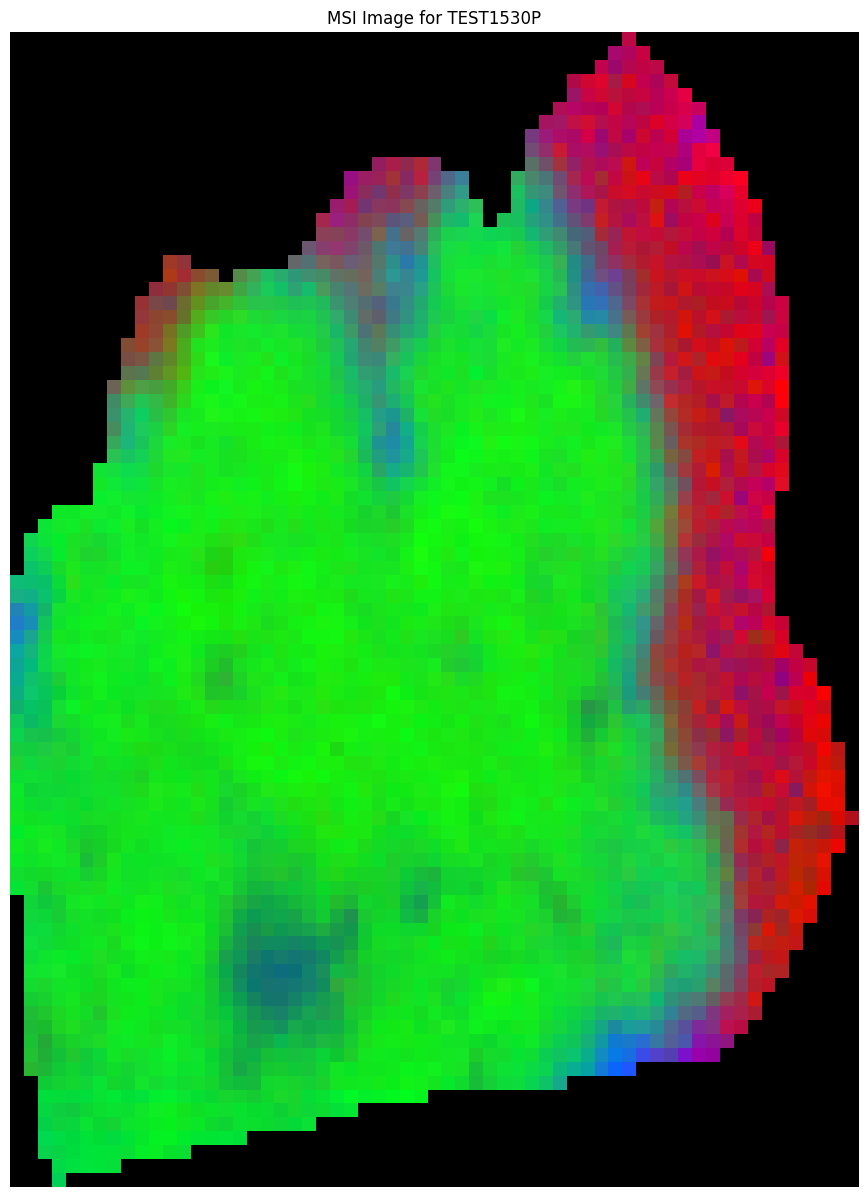

In [64]:
plt.figure(figsize=(15, 15))
plt.imshow(msi_image, cmap='gray')
plt.axis('off')
plt.title(f"MSI Image for {SAMPLE_ID}")

In [65]:
prova = intensities.reshape(-1, intensities.shape[-1])
print(f"Prova shape: {prova.shape}")

filtered_intensities = prova[prova.sum(axis=1) > 0]
print(f"Filtered intensities shape: {filtered_intensities.shape}")

Prova shape: (5063, 2973)
Filtered intensities shape: (3573, 2973)


In [66]:
# Compute PCA 
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_embedding = pca.fit_transform(filtered_intensities)

# Normalize the PCA embedding
pca_embedding = (pca_embedding - np.min(pca_embedding)) / (np.max(pca_embedding) - np.min(pca_embedding))


/data/leuven/366/vsc36687/miniconda3/envs/FOCUS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0.5, 1.0, 'UMAP Embedding for TEST1530P')

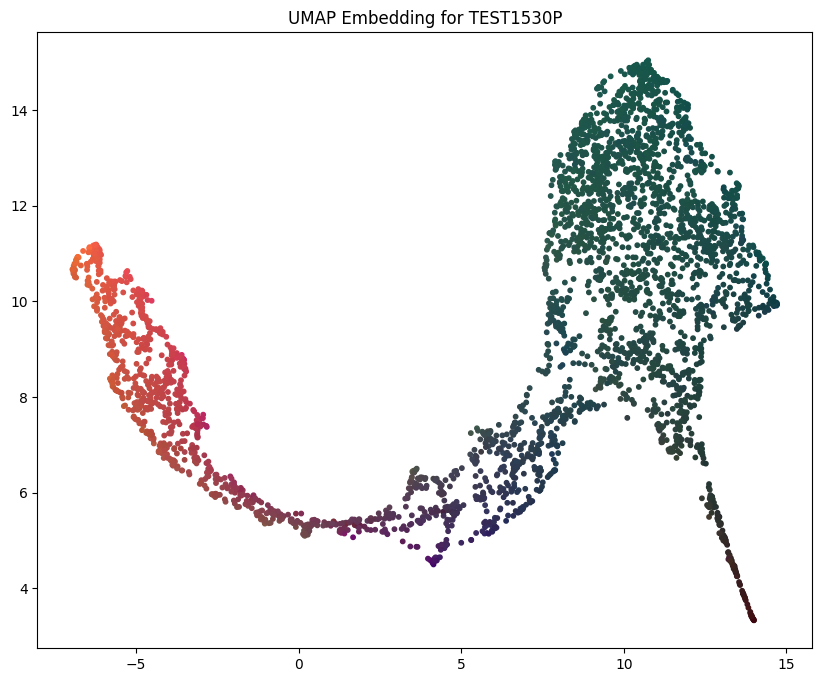

In [67]:
import umap

# Perform UMAP dimensionality reduction
umap_model = umap.UMAP(n_components=2)
umap_embedding = umap_model.fit_transform(filtered_intensities)

# Plot UMAP embedding
plt.figure(figsize=(10, 8))
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], s=10, c=pca_embedding)
plt.title(f"UMAP Embedding for {SAMPLE_ID}")